Questions:
1. What neighborhood has highest average sale price?

2. How does squarefootage influence sale price?

3. How does condition/quality influence sale price?

4. Are there any outliers?

5. How does number of bedrooms influence sale price?

6. Does Season when house is sold effect sale price?

7. Does having a pool increase sale price?

8. Does building type (townhouse, single family) effect sale price?

#Problem Space:
The goal of this project is to understand which factors influence home sale prices in Ames, Iowa. Housing prices vary widely, and features such as square footage, neighborhood, quality, condition, and building type may explain these differences. This matters because buyers, sellers, and real-estate professionals rely on accurate pricing to make informed financial decisions.

The analysis focuses on what features affect price, why certain attributes raise or lower value, who is impacted (buyers, sellers, analysts), where the data comes from (Ames, Iowa), and when the homes were sold (timing and season). Overall, the project aims to use data to better understand how different property characteristics shape a home’s market value.

Import data from kaggle

https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data


In [3]:
import os
os.environ["KAGGLE_USERNAME"] = "navin88"
os.environ["KAGGLE_KEY"] = "79688abc11902900b53ec32bad5aaece"
!pip install -q kaggle
!kaggle competitions download -c house-prices-advanced-regression-techniques -p /content

  0% 0.00/199k [00:00<?, ?B/s]
100% 199k/199k [00:00<00:00, 339MB/s]


#Unzip, Import pandas and read in data

In [4]:
!unzip -o /content/house-prices-advanced-regression-techniques.zip -d /content/house_prices
import pandas as pd
train = pd.read_csv("/content/house_prices/train.csv")
test  = pd.read_csv("/content/house_prices/test.csv")

Archive:  /content/house-prices-advanced-regression-techniques.zip
  inflating: /content/house_prices/data_description.txt  
  inflating: /content/house_prices/sample_submission.csv  
  inflating: /content/house_prices/test.csv  
  inflating: /content/house_prices/train.csv  


#Get idea of shape and features of data set

In [19]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("\nTrain columns:")
print(train.columns.tolist())
print("\nTest columns:")
print(test.columns.tolist())

Train shape: (1460, 82)
Test shape: (1459, 81)

Train columns:
['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'E

#1. What neighborhood has highest average sale price?

Average Sale Price by Neighborhood:
Neighborhood
NoRidge    335295.317073
NridgHt    316270.623377
StoneBr    310499.000000
Timber     242247.447368
Veenker    238772.727273
Somerst    225379.837209
ClearCr    212565.428571
Crawfor    210624.725490
CollgCr    197965.773333
Blmngtn    194870.882353
Gilbert    192854.506329
NWAmes     189050.068493
SawyerW    186555.796610
Mitchel    156270.122449
NAmes      145847.080000
NPkVill    142694.444444
SWISU      142591.360000
Blueste    137500.000000
Sawyer     136793.135135
OldTown    128225.300885
Edwards    128219.700000
BrkSide    124834.051724
BrDale     104493.750000
IDOTRR     100123.783784
MeadowV     98576.470588
Name: SalePrice, dtype: float64


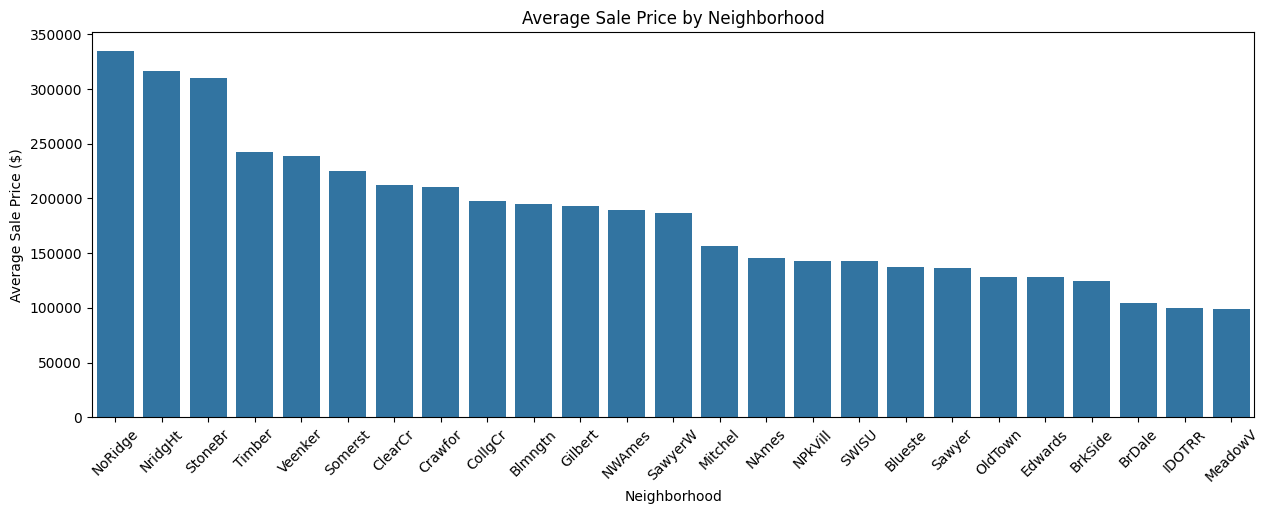

In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Avg sale price by building type
bldg_prices = (
    train.groupby("Neighborhood")["SalePrice"]
         .mean()
         .sort_values(ascending=False)
)

print("Average Sale Price by Neighborhood:")
print(bldg_prices)

# grapgh
plt.figure(figsize=(15,5))
sns.barplot(
    x=bldg_prices.index,
    y=bldg_prices.values
)

plt.title("Average Sale Price by Neighborhood")
plt.ylabel("Average Sale Price ($)")
plt.xlabel("Neighborhood")
plt.xticks(rotation=45)
plt.show()

From the visual, it is clear that neighborhood has a strong effect on a homes average sale price. For example, the average sale price in Northridge is about 335,295 dollars, while in MeadowV it is only 98,576 dollars. This creates a disparity of more than 200,000 dollars, clearly showing that the neighborhood a house is located in greatly influences its sale price.


#2. How does squarefootage influence sale price?

Correlation (GrLivArea vs SalePrice): 0.7086244776126523


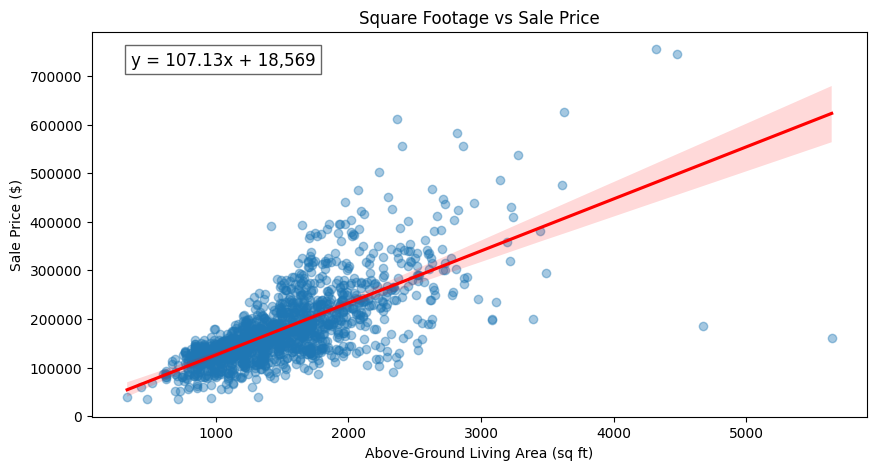

In [47]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# correlation between square footage and price
corr = train["GrLivArea"].corr(train["SalePrice"])
print("Correlation (GrLivArea vs SalePrice):", corr)

# ift linear regression line
m, b = np.polyfit(train["GrLivArea"], train["SalePrice"], 1)
equation = f"y = {m:.2f}x + {b:,.0f}"

# Scatterplot with line
plt.figure(figsize=(10,5))
ax = sns.regplot(
    x=train["GrLivArea"],
    y=train["SalePrice"],
    scatter_kws={"alpha":0.4},
    line_kws={"color":"red"}
)

# add equation on plot
plt.text(
    0.05, 0.95,
    equation,
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(facecolor="white", alpha=0.6)
)

plt.xlabel("Above-Ground Living Area (sq ft)")
plt.ylabel("Sale Price ($)")
plt.title("Square Footage vs Sale Price")
plt.show()


Square footage has a strong positive impact on sale price.
The correlation between above-ground living area (GrLivArea) and SalePrice is 0.7086, indicating a strong linear relationship. The regression equation:

SalePrice = 107.13 × GrLivArea + 18,569

shows that, on average, each additional square foot adds about \$107 to the home’s value. The scatterplot confirms that larger homes consistently sell for more, although price still varies due to a multitude of different features.

#3. How does condition/quality influence sale price?

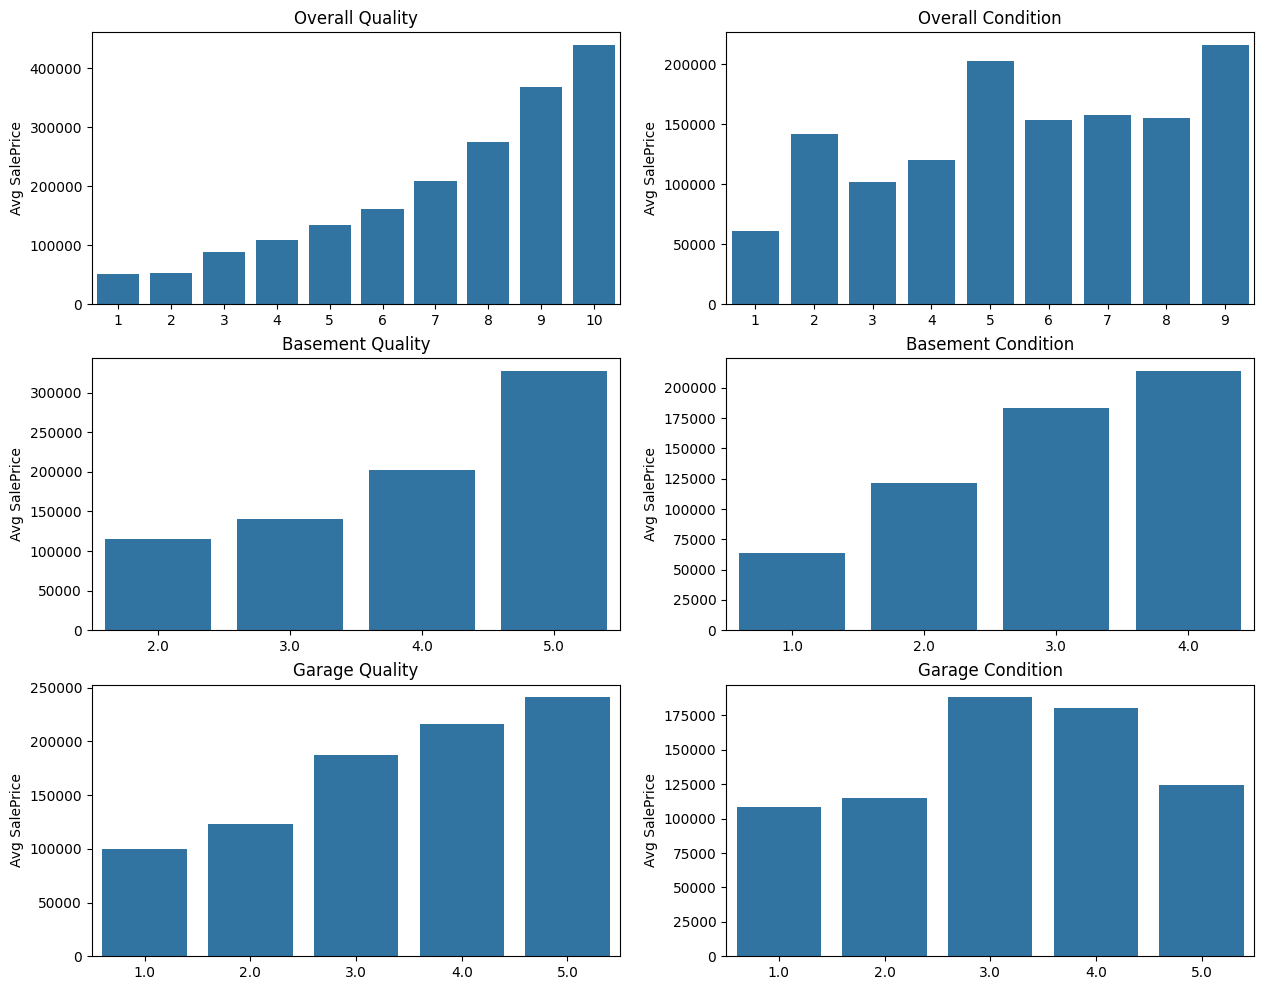

In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#  map categorical quality scores to nums
qual_map = {
    "Po": 1,  # Poor
    "Fa": 2,  # Fair
    "TA": 3,  # Typical/Average
    "Gd": 4,  # Good
    "Ex": 5   # Excellent
}

cond_map = {
    "Po": 1,
    "Fa": 2,
    "TA": 3,
    "Gd": 4,
    "Ex": 5
}

# Apply mappings
train["BsmtQual_num"]   = train["BsmtQual"].map(qual_map)
train["BsmtCond_num"]   = train["BsmtCond"].map(cond_map)
train["GarageQual_num"] = train["GarageQual"].map(qual_map)
train["GarageCond_num"] = train["GarageCond"].map(cond_map)

# Prepare features for plotting
features = {
    "OverallQual": "Overall Quality",
    "OverallCond": "Overall Condition",
    "BsmtQual_num": "Basement Quality",
    "BsmtCond_num": "Basement Condition",
    "GarageQual_num": "Garage Quality",
    "GarageCond_num": "Garage Condition"
}

# Create plots
plt.figure(figsize=(15, 12))

for i, (col, title) in enumerate(features.items(), 1):
    plt.subplot(3, 2, i)
    grouped = train.groupby(col)["SalePrice"].mean()
    sns.barplot(x=grouped.index, y=grouped.values, linewidth=1)
    plt.title(title)
    plt.xlabel("")
    plt.ylabel("Avg SalePrice")

plt.show()


Condition and quality have a very strong impact on sale price — especially overall quality.

The Overall Quality chart shows a clear upward trend:
homes rated 1–3 sell for under 100 dollars on average, while homes rated 9–10 exceed \$350k–\$450k. This makes OverallQual one of the strongest predictors of price in the entire dataset.

Overall Condition shows a weaker and less consistent pattern. Some mid-range condition ratings (like 5 and 9) correlate with higher sale prices, but overall condition does not rise as smoothly as overall quality.

For Basement Quality/Condition and Garage Quality, the trend is still clear:
higher quality ratings lead to substantially higher average sale prices. Homes with excellent basement condition/qual or garage quality sell for two to three times more than homes rated poor or fair.

For Garage condition sale prices spike at 3.0 and decrease till 5.0

#4. Are there any outliers?


Number of outliers: 61
Lower bound: 3937.5
Upper bound: 340037.5
Min price: 34900
Max price: 755000


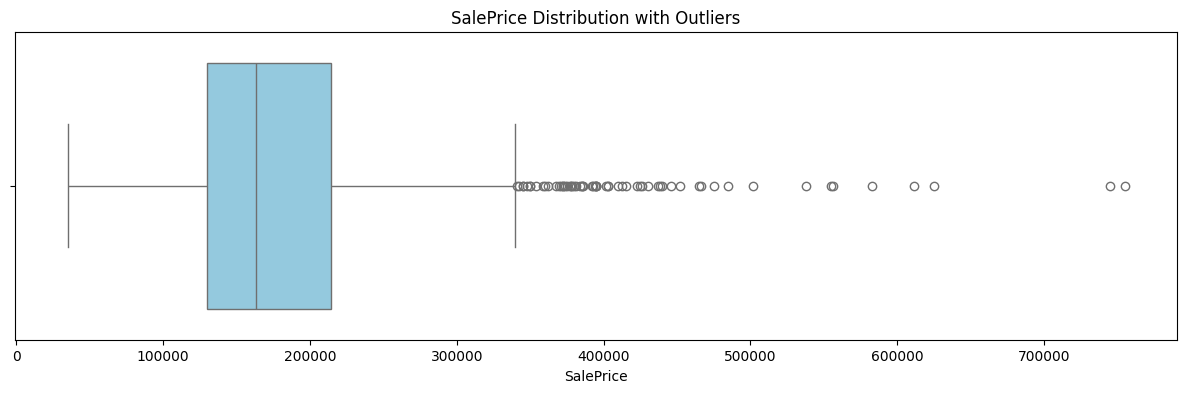

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Compute IQR boundaries
Q1 = train["SalePrice"].quantile(0.25)
Q3 = train["SalePrice"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = train[(train["SalePrice"] < lower_bound) | (train["SalePrice"] > upper_bound)]

print("Number of outliers:", len(outliers))
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Min price:", train["SalePrice"].min())
print("Max price:", train["SalePrice"].max())

# graph outliers
plt.figure(figsize=(15, 4))
sns.boxplot(x=train["SalePrice"], color="skyblue")
plt.title("SalePrice Distribution with Outliers")
plt.show()

Yes there are clear outliers in the SalePrice distribution.
Using the IQR rule, the lower bound is 3,937 dollars and the upper bound is 340,037 dollars.
Any home priced above this range is considered an outlier.

In total, the dataset contains 61 outlier homes, almost all on the high end of the price range.
The minimum sale price is 34,900 dollars and the maximum reaches 755,000 dollars, with the boxplot showing a long right tail of unusually expensive properties.

#5. How does number of bedrooms influence sale price?

Average Sale Price by Number of Bedrooms:
BedroomAbvGr
6    143779.000000
2    158197.659218
1    173162.420000
5    180819.047619
3    181056.870647
8    200000.000000
4    220421.253521
0    221493.166667
Name: SalePrice, dtype: float64


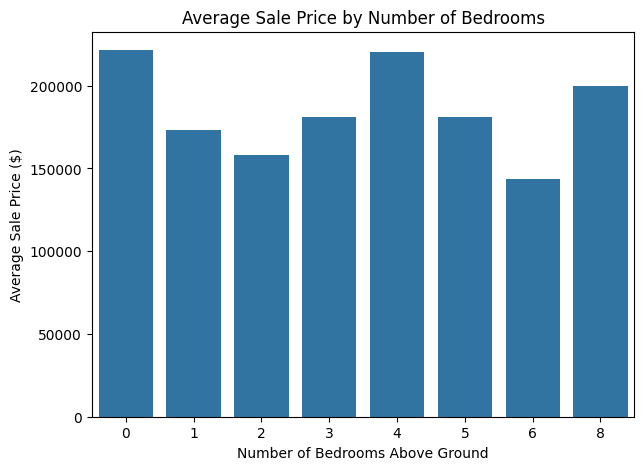

In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Average sale price by number of bedrooms
bed_prices = (
    train.groupby("BedroomAbvGr")["SalePrice"]
         .mean()
         .sort_values()
)

print("Average Sale Price by Number of Bedrooms:")
print(bed_prices)

# Visualization
plt.figure(figsize=(7,5))
sns.barplot(
    x=bed_prices.index,
    y=bed_prices.values
)

plt.title("Average Sale Price by Number of Bedrooms")
plt.xlabel("Number of Bedrooms Above Ground")
plt.ylabel("Average Sale Price ($)")
plt.show()

Number of bedrooms shows only a weak, inconsistent relationship with sale price.
Average sale prices by bedroom count varies widely:

0 bedrooms: $221,493

4 bedrooms: $220,421

8 bedrooms: $200,000

3 bedrooms: $181,057

5 bedrooms: $180,819

1 bedroom: $173,162

2 bedrooms: $158,198

6 bedrooms: $143,779

While homes with 4–0 bedrooms tend to sell for more on average, increasing bedroom count does not produce an upward trend. Prices fluctuate a bunch, showing that bedroom count alone is not a strong predictor of home value.

#6. Does Season when house is sold effect sale price?

Average Sale Price by Season:
SeasonSold
Winter    182741.692308
Spring    174628.733925
Summer    182282.665025
Fall      188285.272727
Name: SalePrice, dtype: float64


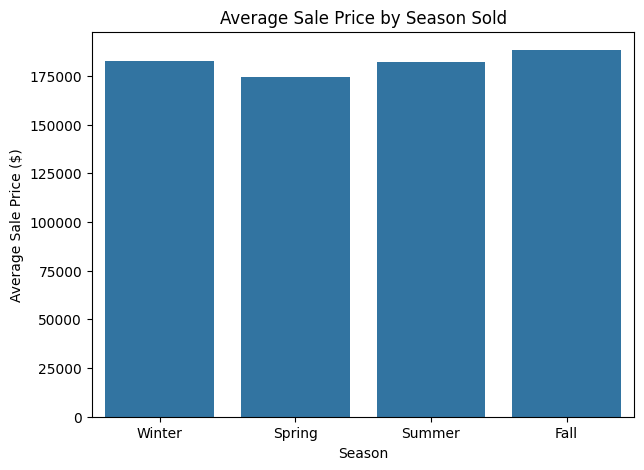

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Map month to season
def month_to_season(m):
    if m in [12, 1, 2]:
        return "Winter"
    elif m in [3, 4, 5]:
        return "Spring"
    elif m in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

train["SeasonSold"] = train["MoSold"].apply(month_to_season)

# Avg sale price by season
season_prices = (
    train.groupby("SeasonSold")["SalePrice"]
         .mean()
         .reindex(["Winter", "Spring", "Summer", "Fall"])
)

print("Average Sale Price by Season:")
print(season_prices)

# Visualization
plt.figure(figsize=(7,5))
sns.barplot(x=season_prices.index, y=season_prices.values)
plt.title("Average Sale Price by Season Sold")
plt.xlabel("Season")
plt.ylabel("Average Sale Price ($)")
plt.show()


Season does have a modest effect on sale price, but the differences are not dramatic.
Average sale prices by season are:

Fall: $188,285

Winter: $182,742

Summer: $182,283

Spring: $174,629

Fall has the highest average prices, while Spring has the lowest.
However, the overall spread between seasons is relatively small (about $14k difference between highest and lowest), suggesting that seasonality influences price but is not a major driver compared to other factors.

#7. Does having a pool increase sale price?

Average price (0 = no pool, 1 = pool):
HasPool
0    180404.663455
1    288138.571429
Name: SalePrice, dtype: float64


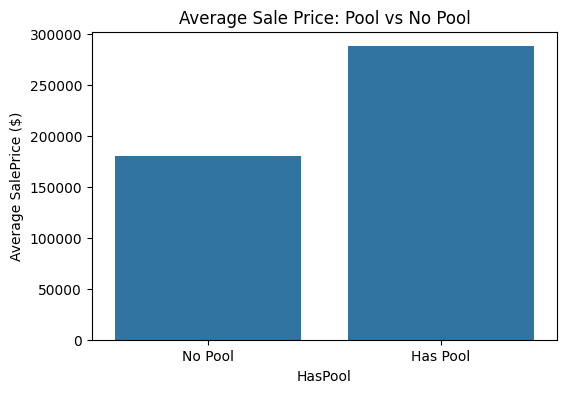

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create a indicator for having a pool
train["HasPool"] = (train["PoolArea"] > 0).astype(int)

# Compare avg sale price
avg_prices = train.groupby("HasPool")["SalePrice"].mean()
print("Average price (0 = no pool, 1 = pool):")
print(avg_prices)

# Visualization
plt.figure(figsize=(6,4))
sns.barplot(x=avg_prices.index, y=avg_prices.values)
plt.xticks([0,1], ["No Pool", "Has Pool"])
plt.ylabel("Average SalePrice ($)")
plt.title("Average Sale Price: Pool vs No Pool")
plt.show()

Yes having a pool is associated with a significantly higher sale price.
Homes without a pool have an average sale price of $180,405, while homes with a pool average 288,138 dollars

That’s roughly a 108,000 dollars increase on average for homes that have a pool.

However, very few houses in the dataset actually have pools, so this increase may partly reflect that pool homes tend to also be larger, higher-quality, and located in more expensive neighborhoods.

#8. Does building type (townhouse, single family, etc) effect sale price?

Average Sale Price by Building Type:
BldgType
1Fam      185763.807377
TwnhsE    181959.342105
Twnhs     135911.627907
Duplex    133541.076923
2fmCon    128432.258065
Name: SalePrice, dtype: float64


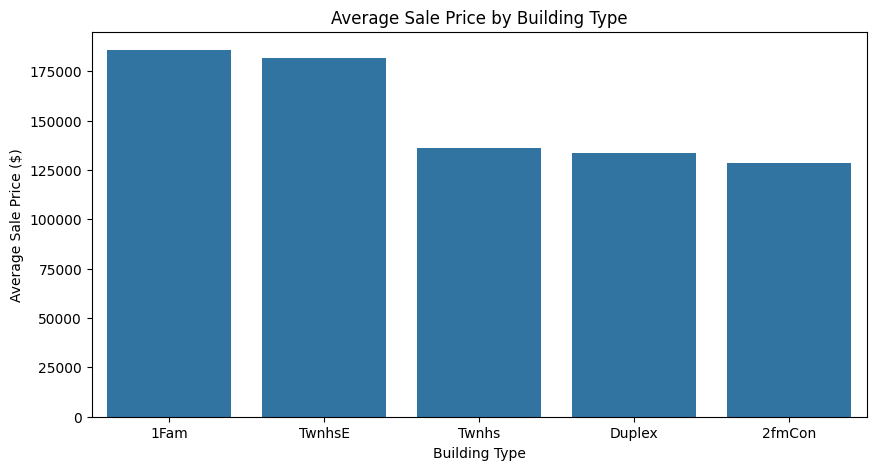

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Avg sale price by building type
bldg_prices = (
    train.groupby("BldgType")["SalePrice"]
         .mean()
         .sort_values(ascending=False)
)

print("Average Sale Price by Building Type:")
print(bldg_prices)

# Visualization
plt.figure(figsize=(10,5))
sns.barplot(
    x=bldg_prices.index,
    y=bldg_prices.values
)

plt.title("Average Sale Price by Building Type")
plt.ylabel("Average Sale Price ($)")
plt.xlabel("Building Type")
plt.show()

Yes building type does affect sale price.
Single-family homes (1Fam) have the highest average sale price at 185,764 dollars, followed closely by end-unit townhomes (TwnhsE) at 181,959 dollars.
Other building types sell for noticeably less:

Twnhs: $135,912

Duplex: $133,541

2fmCon: $128,432